# Tracking My Chess Career Through Blitz, Rapid, and Bullet

Tom White  
CPSC 222, Spring 2026


## Introduction

Chess matters to me because it gives quick, measurable feedback on decision-making, focus, pattern recognition, and practice habits. I play different time controls on Chess.com, and I wanted to use my own game history to find patterns that could help me study more intentionally instead of relying only on vibes.

My dataset is stored as CSV files. The source table is imsogarb69_all_2604212016.csv, my personal Chess.com game export. From that raw file, I prepared three project tables:

- `games_clean.csv`: one row per blitz, rapid, or bullet game.
- `calendar_table.csv`: one row per calendar date from my first included game through my last included game.
- `daily_summary.csv`: one row per calendar date with daily game counts, win/loss/draw totals, time-control counts, and daily rating summaries.

The game table is collected from Chess.com. The calendar table is a separate date lookup table generated from standard calendar rules, similar to a weekday metadata source. The daily summary table is aggregated from the cleaned game table and joined with the calendar table on `date`, so days with no games are still represented.

Important attributes include `date` (temporal), `timeClass` (nominal), `userColor` (nominal), `userRating` and `opponentRating` (numeric rating attributes), `rating_diff` (numeric derived attribute), `weekday` (nominal calendar attribute), `games_played_so_far_today` (count), `recent_win_rate_5` (numeric proportion), and `result_group` (nominal class label). The classification task predicts `result_group` as win versus loss for decisive games; draws are excluded from classification but retained for descriptive analysis.

My main hypothesis is that opponent strength, will matter much more than color, time of day, or weekday. The stakeholders are me as the player, ir abyone that wants to look at there chess stats.   


In [1]:
import utils
import pandas as pd

pd.set_option("display.max_columns", 50)

games, calendar, daily = utils.load_data()

utils.dataset_table_overview(games, calendar, daily)
utils.project_scope_summary_df(games, daily)
utils.time_control_distribution(games)


Dataset Table Overview:
                table  rows  columns
0     games_clean.csv  1623       41
1  calendar_table.csv  1612        8
2   daily_summary.csv  1612       21

Project Scope Summary:
                          metric       value
0                 Games analyzed        1623
1          Calendar days sampled        1612
2            Active playing days         331
3                     First date  2021-04-09
4                      Last date  2025-09-06
5               Overall win rate       0.586
6  Average games per sampled day        1.01
7   Average games per active day         4.9

Time Control Distribution:
  timeClass  games     share
0     rapid    678  0.417745
1     blitz    596  0.367221
2    bullet    349  0.215034



The source Chess.com export contains 1,678 rows before filtering. The prepared project tables are `games_clean.csv` with 1,623 cleaned game instances, `calendar_table.csv` with 1,612 date instances, and `daily_summary.csv` with 1,612 daily instances. The date range is April 9, 2021 through September 6, 2025. There are 331 active playing days, so the calendar and daily summary tables make the daily sampling explicit even when I did not play that day. Rapid is the largest time-control group, followed by blitz and bullet.


## Data Preparation

The raw Chess.com export needed several cleaning steps before analysis. I filtered to blitz, rapid, and bullet games; stripped extra whitespace; renamed the raw move-count columns; parsed dates and start/end times; converted ratings and move counts to numeric values; created win/loss/draw indicators; and engineered features for rating difference, opponent strength bucket, time-of-day bucket, opening family, games already played that day, and recent five-game win rate.

The raw export has missing accuracy values for many older games and one missing move count. I kept those games because the missing fields are not used by the classifiers, and the class label, ratings, time control, color, and date are still valid. For daily rows with zero games, count fields are set to zero and hour fields use `-1` to mark that no game was played.


In [2]:
utils.validate_join_integrity(games, calendar, daily)

print(games[[
    "date",
    "timeClass",
    "userColor",
    "userRating",
    "opponentRating",
    "move_count",
    "result_group",
    "rating_diff",
    "opening_family",
    "games_played_so_far_today",
    "recent_win_rate_5",
    "weekday",
    "hour_bucket_et",
]].head(5))


Join Integrity Checks:
                                      check  passed  details
0           game dates included in calendar    True        0
1          daily dates match calendar dates    True        0
2  daily table has one row per calendar day    True     1612

        date timeClass userColor  userRating  opponentRating  move_count  \
0 2021-04-09    bullet     white         247             499        17.0   
1 2021-04-09     rapid     black         593             420        44.0   
2 2021-04-10     rapid     black         467             596        10.0   
3 2021-04-10     rapid     white         373             466        36.0   
4 2021-04-10     rapid     white         308             418        52.0   

  result_group  rating_diff                              opening_family  \
0         loss         -252  Nimzowitsch Defense Kennedy Paulsen Attack   
1          win          173             Ruy Lopez Opening Cozio Defense   
2         loss         -129     Queens Gambit Decl

The join checks confirm that every game date exists in the calendar table and that the daily table has one row for every calendar date. The displayed rows show the cleaned game-level format used throughout the rest of the report.


## Exploratory Data Analysis

I use game-level aggregation for color, time control, opponent strength, time of day, and openings. I use daily and weekly aggregation for activity and rating trends. Summary statistics help identify the typical rating range, game volume, and rating-gap spread before looking at the plots.


In [3]:
print("Daily activity summary:")
print(daily[["games_played", "wins", "losses", "draws", "win_rate"]].describe())

print()
print("Game-level numeric summary:")
print(games[["userRating", "opponentRating", "rating_diff", "recent_win_rate_5"]].describe())


Daily activity summary:
       games_played        wins       losses        draws     win_rate
count   1612.000000  1612.00000  1612.000000  1612.000000  1612.000000
mean       1.006824     0.58995     0.362903     0.053970     0.112532
std        3.409641     2.12285     1.305268     0.273271     0.268069
min        0.000000     0.00000     0.000000     0.000000     0.000000
25%        0.000000     0.00000     0.000000     0.000000     0.000000
50%        0.000000     0.00000     0.000000     0.000000     0.000000
75%        0.000000     0.00000     0.000000     0.000000     0.000000
max       80.000000    47.00000    30.000000     4.000000     1.000000

Game-level numeric summary:
        userRating  opponentRating  rating_diff  recent_win_rate_5
count  1623.000000     1623.000000  1623.000000        1623.000000
mean    711.923598      658.913740    53.009858           0.585695
std     260.738346      269.963483   178.335557           0.233297
min     100.000000      100.000000 -1199

The summaries show that most sampled days had no games, which is why the active playing day count matters. At the game level, rating difference has a wide spread, making it a strong candidate predictor for wins and losses.


<Axes: title={'center': 'Games Played Per Week by Time Control'}, xlabel='Week Starting', ylabel='Games Played'>

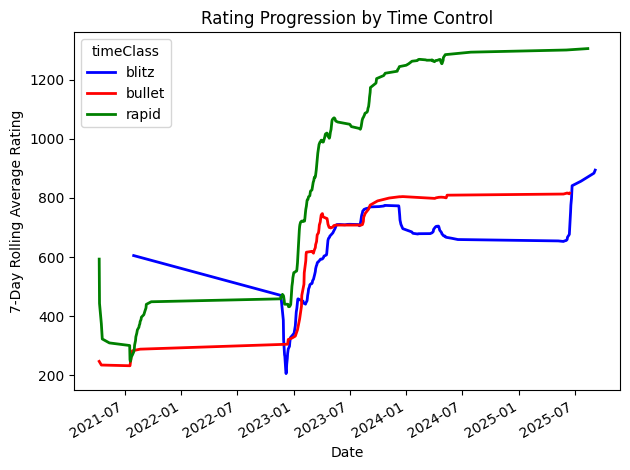

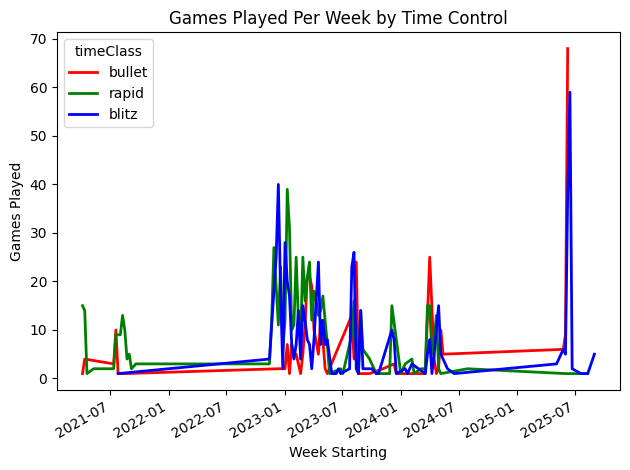

In [4]:
utils.plot_rating_progression(games)
utils.plot_games_per_week(games)


The trend plots show how my rating and activity changed over time by time control. This is useful context because a model trained on all games is combining several playing periods and skill levels.


### Win Rate By Color And Time Control

The next plots compare win rate across color and time control. These are simple group means, so they are descriptive rather than proof of causation.


<Axes: title={'center': 'Win Rate by Time Control'}, xlabel='Time Control', ylabel='Win Rate'>

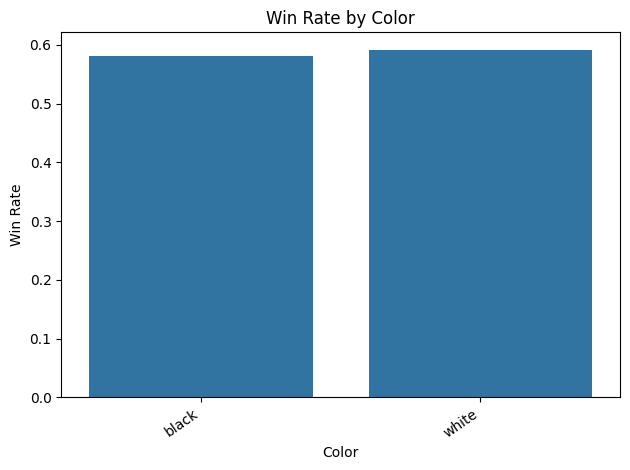

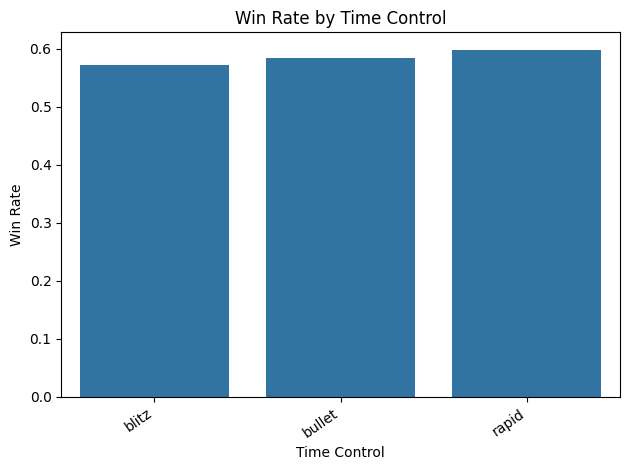

In [5]:
utils.plot_win_rate_by_color(games)
utils.plot_win_rate_by_time_control(games)


White and Black performance are very close: about 59.2% versus 58.0% using all games. Rapid has the highest win rate at about 59.9%, followed by bullet at 58.5% and blitz at 57.2%, but the differences are small.


### Win Rate By Opponent Strength And Time Of Day

Opponent strength should matter because rating is designed to summarize past performance. Time of day is more personal: it might reflect energy, schedule, or when I tend to play casually.


<Axes: title={'center': 'Win Rate by Time of Day (ET)'}, xlabel='Time of Day', ylabel='Win Rate'>

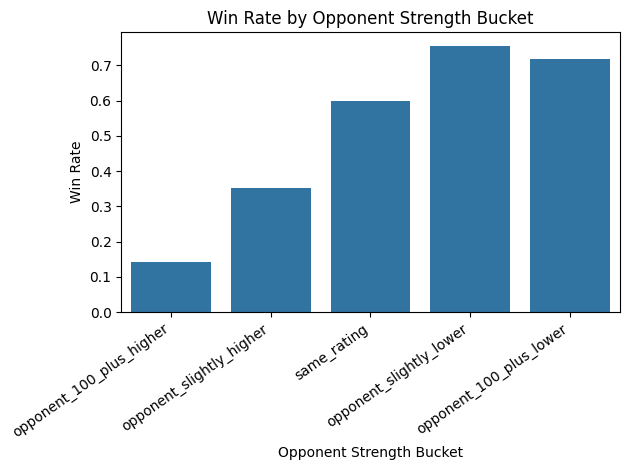

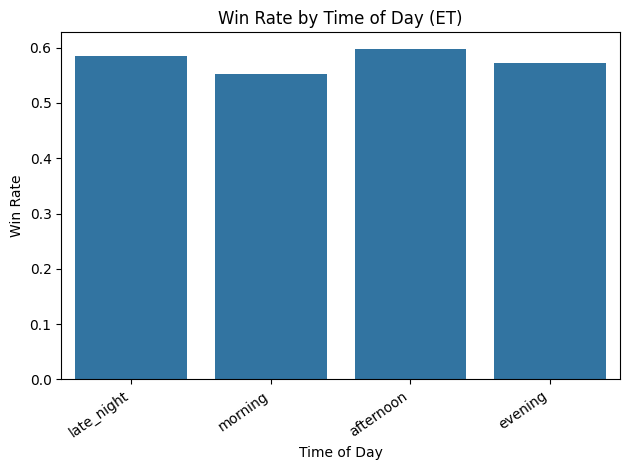

In [6]:
utils.plot_win_rate_by_opponent_strength(games)
utils.plot_win_rate_by_time_of_day(games)


Opponent strength is the clearest EDA pattern. I win far more often against lower-rated opponents and far less often against opponents rated at least 100 points above me. Time of day is weaker: afternoon is the best bucket, while morning is lowest, but morning has very few games.


### Chess Openings

For openings, I group by opening family and only inspect families with at least eight games. This avoids overreacting to an opening I only played once or twice.


In [7]:
white_openings = utils.weakest_openings(games, "white")
black_openings = utils.weakest_openings(games, "black")

print("Weakest White opening families:")
print(white_openings[["opening_family", "games", "win_rate", "avg_rating_diff"]].head(10))

print()
print("Weakest Black opening families:")
print(black_openings[["opening_family", "games", "win_rate", "avg_rating_diff"]].head(10))


Weakest White opening families:
                                      opening_family  games  win_rate  \
0                    French Defense Knight Variation     15  0.333333   
1  Ponziani Opening Jaenisch Counterattack 4.d4 exd4     12  0.416667   
2                       Ponziani Opening 3...d6 4.d4     19  0.421053   
3                                 Kings Pawn Opening     11  0.454545   
4                                   Philidor Defense     14  0.500000   
5  Scandinavian Defense Mieses Kotrc Variation 3.Nc3     12  0.500000   
6          Kings Pawn Opening Kings Knight Variation     30  0.533333   
7                                     Englund Gambit     11  0.545455   
8  Queens Pawn Opening Accelerated London System ...     11  0.545455   
9          Queens Pawn Opening Horwitz Defense 2.Bf4     11  0.545455   

   avg_rating_diff  
0        -2.866667  
1        53.500000  
2        46.842105  
3       152.090909  
4        22.500000  
5        61.833333  
6        25.50000

The opening summaries are useful for chess improvement because they point to specific study targets. My weakest White opening group is the French Defense Knight Variation, and one of my weakest Black groups is the Giuoco Piano Game.


### Hypothesis Test 1: Color And Win Rate

$H_0$: My decisive-game win rate is the same when I play White and Black.  
$H_1$: My decisive-game win rate is different when I play White and Black.

I use a two-proportion z-test because the comparison is between two proportions: White win rate and Black win rate.


In [8]:
color_test = utils.run_hypothesis_test(games)
print(color_test)


                                    test  white_wins  white_total  black_wins  \
0  White vs Black decisive-game win rate         475          760         476   

   black_total  white_win_rate  black_win_rate  z_stat   p_value  \
0          776           0.625        0.613402   0.468  0.639785   

   significant_at_0_05  
0                False  


The p-value is about 0.640, so I fail to reject the null hypothesis at alpha = 0.05. In this dataset, there is not strong evidence that my decisive-game win rate depends on whether I played White or Black.


### Hypothesis Test 2: Time Control And Result

$H_0$: Time control and decisive-game result are independent.  
$H_1$: Time control and decisive-game result are associated.

I use a chi-square test of independence because both variables are categorical: time control and win/loss result.


In [9]:
time_control_test = utils.run_time_control_chi_square_test(games)


Observed Counts:
result_group  loss  win
timeClass              
blitz          218  341
bullet         137  204
rapid          230  406

Chi-Square Test Summary:
                       test  chi2_stat  degrees_of_freedom   p_value  \
0  time control vs win/loss   1.825751                   2  0.401368   

   significant_at_0_05  
0                False  



The p-value is about 0.401, so I fail to reject the null hypothesis at alpha = 0.05. The EDA showed small win-rate differences by time control, but this test does not provide strong evidence that time control and win/loss result are associated in my decisive games.


## Classification Results

The class label is `result_group`, converted into a binary target: win = 1 and loss = 0. Draws are excluded so the task is a clean supervised binary classification problem.

To keep the classifiers close to the workflow used in class, I use a numeric feature matrix with `userRating`, `opponentRating`, `rating_diff`, `games_played_so_far_today`, and `recent_win_rate_5`. Categorical attributes such as time control, color, weekday, time of day, and opening family are still analyzed in the EDA section, but they are not included in the classifier feature matrix.

My prediction hypotheses are:

1. `rating_diff` will be the strongest predictor.
2. Opening family may be useful in a future model because some opening groups have low win rates.
3. Time of day and weekday will probably have limited predictive power.
4. The decision tree should outperform kNN because it can learn threshold rules from the numeric rating features.

Both classifiers use a stratified 75/25 train/test split. For kNN, I scale the numeric features with `MinMaxScaler`, fit `KNeighborsClassifier`, predict on the held-out test set, and calculate accuracy plus a confusion matrix. For the decision tree, I fit `DecisionTreeClassifier(criterion="entropy")` with a maximum depth of 5 and evaluate it on the same test set. I compare both models against the majority-class baseline.


Class Label Distribution (win vs loss, draws excluded):
              count  percent
result_group                
win             951    61.91
loss            585    38.09

Majority-Class Baseline Accuracy: 0.6191



<Axes: title={'center': 'Class Distribution'}, xlabel='Outcome', ylabel='Count'>

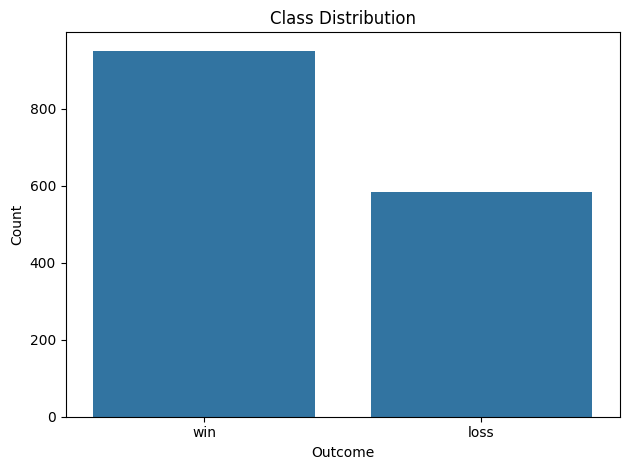

In [10]:
utils.class_label_distribution(games)
utils.majority_class_baseline(games)
utils.plot_class_distribution(games)


The decisive-game class distribution is moderately imbalanced: about 61.9% wins and 38.1% losses. A model needs to beat the 61.9% majority-class baseline to be useful.


In [11]:
knn_results = utils.run_knn_classifier(games, k=5)
dt_results = utils.run_decision_tree_classifier(games, max_depth=5)

print("kNN classification report:")
print(knn_results["report"])

print()
print("Decision Tree classification report:")
print(dt_results["report"])

print()
print("Decision Tree feature importances:")
print(dt_results["importances"].head(10))


kNN Classifier (neighbors=5)
  Accuracy: 0.6536
  Majority baseline: 0.6191
  Confusion matrix:
             predicted_loss  predicted_win
actual_loss              64             82
actual_win               51            187

Decision Tree Classifier (max_depth=5)
  Accuracy: 0.7266
  Majority baseline: 0.6191
  Confusion matrix:
             predicted_loss  predicted_win
actual_loss              56             90
actual_win               15            223

kNN classification report:
              precision    recall  f1-score     support
loss           0.556522  0.438356  0.490421  146.000000
win            0.695167  0.785714  0.737673  238.000000
accuracy       0.653646  0.653646  0.653646    0.653646
macro avg      0.625845  0.612035  0.614047  384.000000
weighted avg   0.642453  0.653646  0.643666  384.000000

Decision Tree classification report:
              precision    recall  f1-score     support
loss           0.788732  0.383562  0.516129  146.000000
win            0.712460  

The kNN classifier reaches about 65.4% accuracy, only a few points above the 61.9% baseline. The decision tree performs better at about 72.7% accuracy. The tree also has better recall for wins, but it still misses many losses, which is expected with an imbalanced dataset.

The feature importances support the main hypothesis: `rating_diff` dominates the decision tree. This means the classifier is mostly learning whether I was higher or lower rated than my opponent.


<Axes: title={'center': 'Decision Tree (first 3 levels)'}>

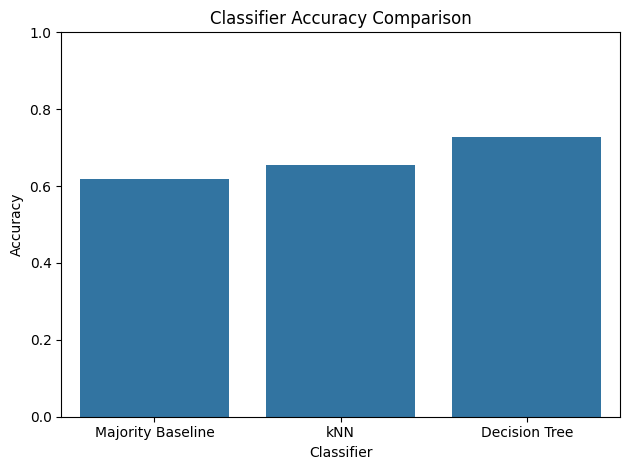

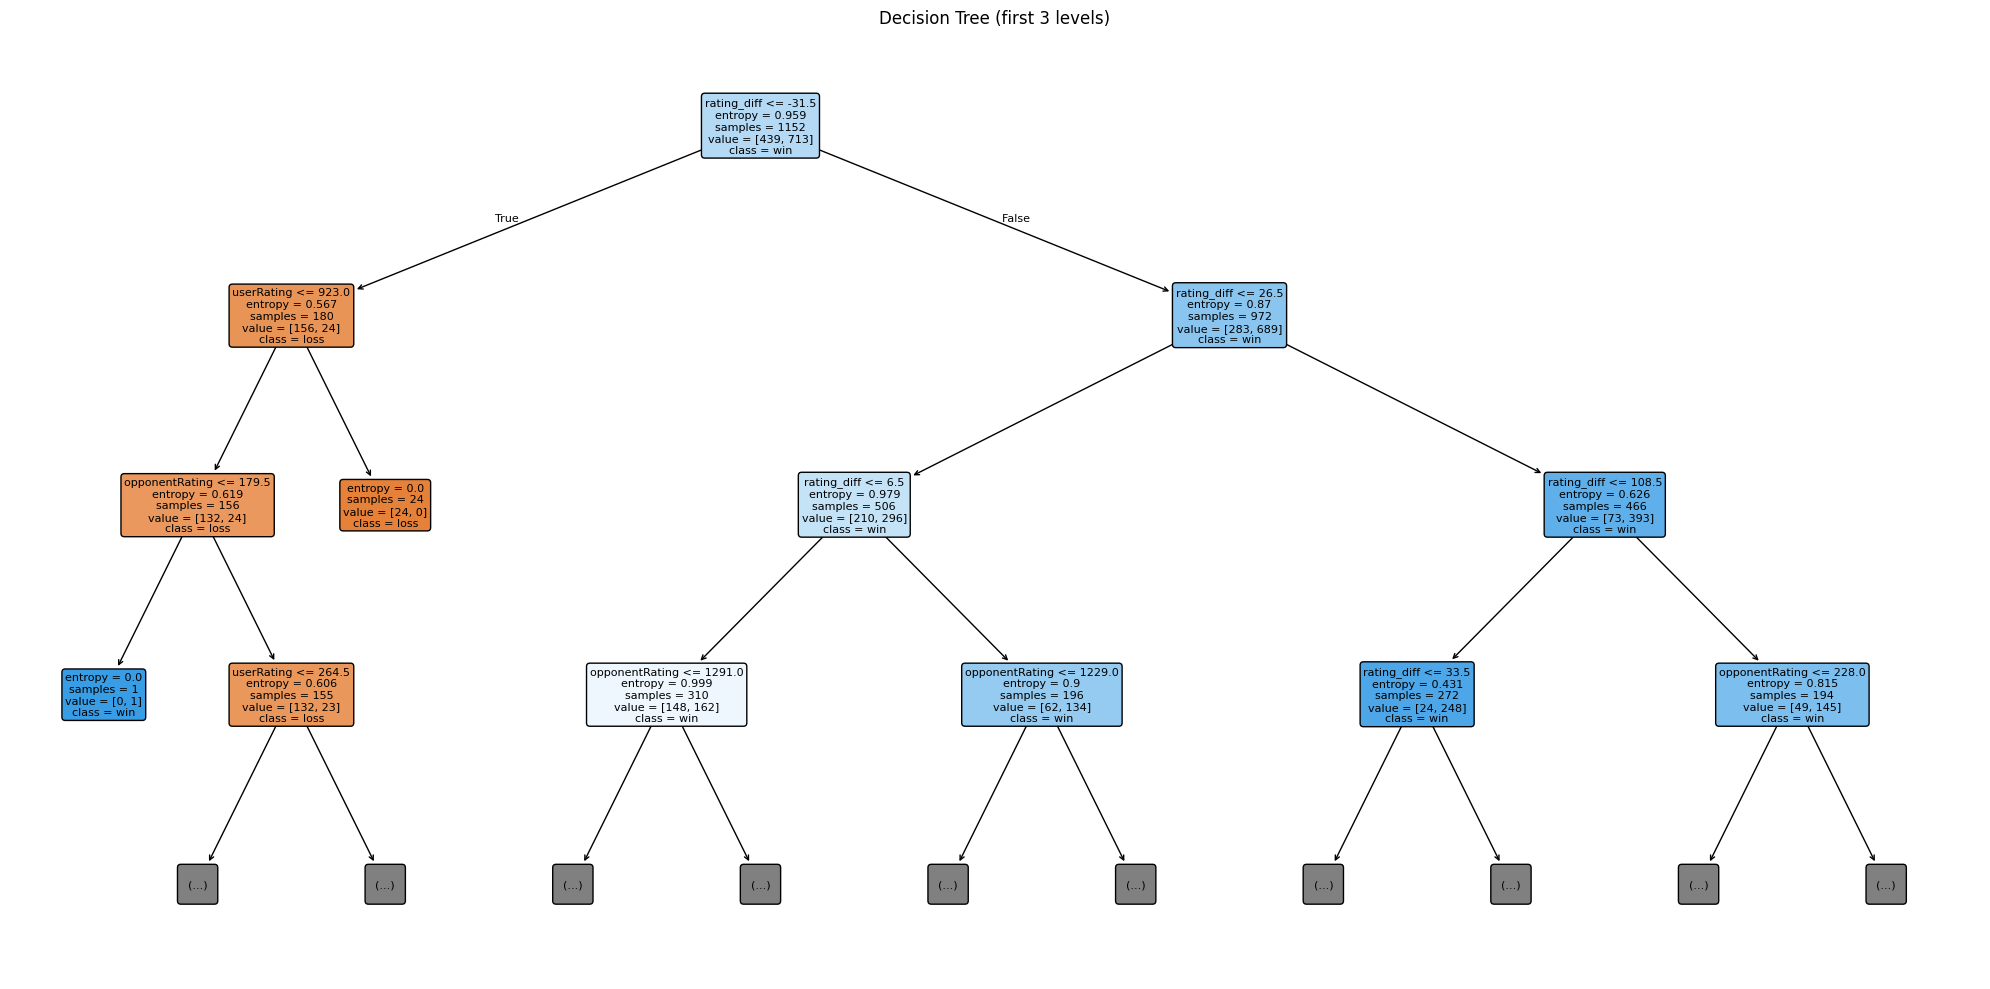

In [12]:
utils.plot_classifier_comparison(knn_results, dt_results)
utils.plot_decision_tree(dt_results)


The comparison plot shows that both classifiers beat the majority baseline, but the decision tree is clearly stronger. The displayed tree levels also make the model easier to explain than kNN because the first splits show which features drive predictions.

The main classification challenges are class imbalance, noisy personal behavior, and feature dominance. Rating difference is so predictive that the other numeric features contribute much less. Categorical signals like weekday, time of day, and opening family may be worth testing later, but I kept them out of this version so the classifier code matches the methods used in class.


## Conclusion

This project used my personal Chess.com history to study patterns in blitz, rapid, and bullet performance. The cleaned dataset includes multiple joined tables, daily sampling across the full date range, exploratory visualizations, statistical hypothesis tests, and two supervised classifiers.

The statistical tests did not find strong evidence that color or time control significantly changed my decisive-game results. The EDA and classification models both point to opponent strength as the most important factor. The decision tree performed best at about 72.7% accuracy, compared with about 65.4% for kNN and 61.9% for the majority-class baseline.

The most useful personal takeaway is that my study time should focus on openings and situations where my win rate is weakest, while remembering that rating difference explains a large part of the result. Better future models could include more recent games, puzzle/study activity, game accuracy, or engine-based mistake counts.

The ethical impact is limited but still worth noting. This analysis should not be used to judge other players or make broad claims about chess ability. It is a self-analysis project, and the results are most appropriate for helping me reflect on my own habits. You would have to add your own csvs to look at your own data.

Sources: the dataset comes from my personal Chess.com game export. The project uses course concepts from CPSC 222 and Python library documentation for pandas, Matplotlib, Seaborn, SciPy, and scikit-learn. I also used chatgpt to check some grammer of this.
